In [10]:
import pandas as pd
import tensorflow as tf
import os
import glob
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
BASE_DIR = '/kaggle/input/datasets/yehongjiang/pokemon-sprites-images/pokemon_images'
CSV_PATH = os.path.join(BASE_DIR, 'pokedex.csv')
df_pokedex = pd.read_csv(CSV_PATH).dropna(subset=['type1', 'primary_color', 'legendary'])

# 2. Get all front sprites
SPRITES_DIR = os.path.join(BASE_DIR, 'sprites')

# This glob pattern searches every subfolder for a 'front' and normal (not shiny) directory containing .png files
search_pattern = os.path.join(SPRITES_DIR, "*", "front", "normal", "*.png")
front_image_paths = glob.glob(search_pattern)

print(f"Found {len(front_image_paths)} front images.")

# 3. Match images to their Pokedex entries
# Sort names from longest to shortest so 'Mew' doesn't accidentally match 'Mewtwo'
pokedex_names = sorted(df_pokedex['name'].astype(str).unique(), key=len, reverse=True)

valid_rows = []
for path in front_image_paths:
    # Extract the folder name
    folder_name = path.split(os.sep)[-4] 
    
    # Find which Pokemon name belongs to this folder
    for name in pokedex_names:
        if name.lower() in folder_name.lower():
            valid_rows.append({'image_path': path, 'name': name})
            break

df_images = pd.DataFrame(valid_rows)

# Merge the images with the CSV data so every image gets its type and color
filtered_df = pd.merge(df_images, df_pokedex, on='name', how='inner')

print(f"Successfully linked {len(filtered_df)} images to their Pokedex metadata")

if len(filtered_df) == 0:
    raise ValueError("Pipeline failed to find images.")

# 4. Encode Multiple Columns
type_encoder = LabelEncoder()
color_encoder = LabelEncoder()

filtered_df['type_encoded'] = type_encoder.fit_transform(filtered_df['type1'])
filtered_df['color_encoded'] = color_encoder.fit_transform(filtered_df['primary_color'])
filtered_df['leg_encoded'] = filtered_df['legendary'].astype(int)

NUM_TYPES = len(type_encoder.classes_)
NUM_COLORS = len(color_encoder.classes_)

# 5. Multi-Input Dataset Pipeline
def load_and_preprocess(path, t1, color, leg):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (96, 96))
    img = tf.image.random_flip_left_right(img)
    img = (img - 127.5) / 127.5 # Normalize to [-1, 1]
    
    return img, {"type_input": t1, "color_input": color, "leg_input": leg}

dataset = tf.data.Dataset.from_tensor_slices((
    filtered_df['image_path'].values, 
    filtered_df['type_encoded'].values, 
    filtered_df['color_encoded'].values, 
    filtered_df['leg_encoded'].values
))

BATCH_SIZE = 64
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(5000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

print("Data pipeline is ready for training")

Found 4086 front images.
Successfully linked 4086 images to their Pokedex metadata
Data pipeline is ready for training


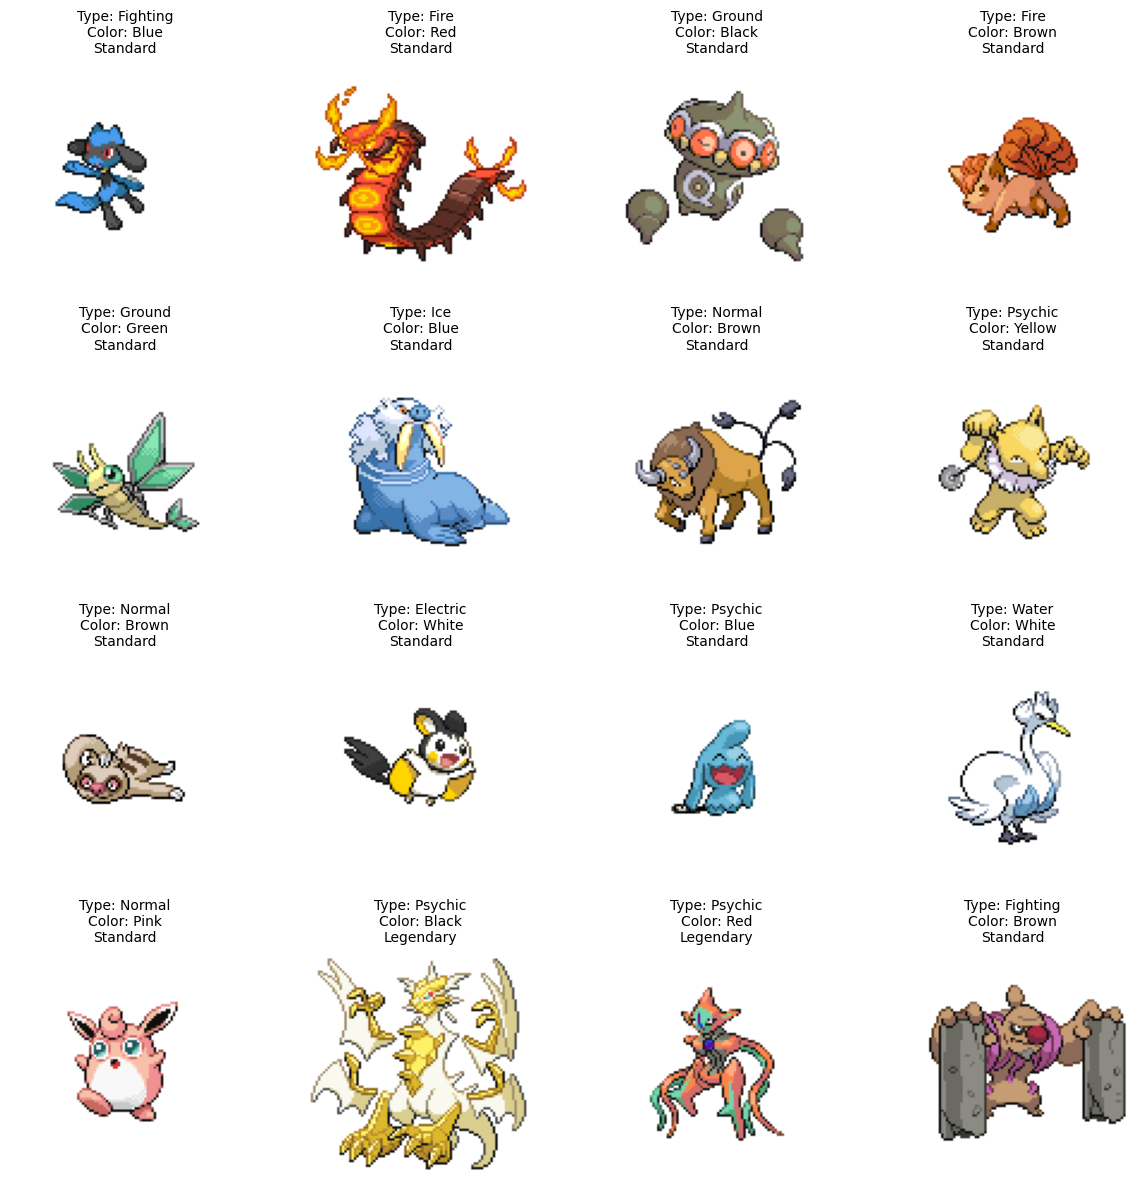

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Grab exactly one batch of 128 images from the pipeline
for images, labels in dataset.take(1):
    plt.figure(figsize=(12, 12))
    
    # We will plot a 4x4 grid (16 images)
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        
        # 1. Un-normalize the image from [-1, 1] back to [0, 1] for matplotlib
        img = (images[i].numpy() + 1.0) / 2.0
        
        # 2. Extract the integer labels for this specific image
        t_idx = labels["type_input"][i].numpy()
        c_idx = labels["color_input"][i].numpy()
        l_idx = labels["leg_input"][i].numpy()
        
        # 3. Use encoders to translate the integers back to text
        type_str = type_encoder.inverse_transform([t_idx])[0]
        color_str = color_encoder.inverse_transform([c_idx])[0]
        leg_str = "Legendary" if l_idx == 1 else "Standard"
        
        # 4. Display the image and its specific request labels
        plt.imshow(img)
        plt.title(f"Type: {type_str}\nColor: {color_str}\n{leg_str}", fontsize=10)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

In [12]:
from tensorflow.keras import layers, Model

def build_multi_generator(latent_dim=100):
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")
    type_input = layers.Input(shape=(1,), name="type_input")
    color_input = layers.Input(shape=(1,), name="color_input")
    leg_input = layers.Input(shape=(1,), name="leg_input")
    
    t_emb = layers.Flatten()(layers.Embedding(NUM_TYPES, 32)(type_input))
    c_emb = layers.Flatten()(layers.Embedding(NUM_COLORS, 32)(color_input))
    l_emb = layers.Dense(16, activation='relu')(leg_input)
    
    combined_input = layers.Concatenate()([noise_input, t_emb, c_emb, l_emb])
    
    # Base Foundation
    x = layers.Dense(3 * 3 * 512, use_bias=False)(combined_input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((3, 3, 512))(x) 
    
    # 3x3 -> 6x6
    x = layers.UpSampling2D(size=(2, 2), interpolation='nearest')(x)
    x = layers.Conv2D(256, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # 6x6 -> 12x12
    x = layers.UpSampling2D(size=(2, 2), interpolation='nearest')(x)
    x = layers.Conv2D(128, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # 12x12 -> 24x24
    x = layers.UpSampling2D(size=(2, 2), interpolation='nearest')(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # 24x24 -> 48x48
    x = layers.UpSampling2D(size=(2, 2), interpolation='nearest')(x)
    x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # 48x48 -> 96x96
    x = layers.UpSampling2D(size=(2, 2), interpolation='nearest')(x)
    output_image = layers.Conv2D(3, kernel_size=3, padding='same', activation='tanh')(x)
    
    return Model(inputs=[noise_input, type_input, color_input, leg_input], outputs=output_image)

In [13]:
def build_multi_discriminator(img_shape=(96, 96, 3)):
    image_input = layers.Input(shape=img_shape, name="image_input")
    type_input = layers.Input(shape=(1,), name="type_input")
    color_input = layers.Input(shape=(1,), name="color_input")
    leg_input = layers.Input(shape=(1,), name="leg_input")
    
    t_emb = layers.Flatten()(layers.Embedding(NUM_TYPES, 32)(type_input))
    c_emb = layers.Flatten()(layers.Embedding(NUM_COLORS, 32)(color_input))
    l_emb = layers.Dense(16, activation='relu')(leg_input)
    
    combined_labels = layers.Concatenate()([t_emb, c_emb, l_emb])
    spatial_labels = layers.Dense(img_shape[0] * img_shape[1])(combined_labels)
    spatial_labels = layers.Reshape((img_shape[0], img_shape[1], 1))(spatial_labels)
    
    x = layers.Concatenate(axis=-1)([image_input, spatial_labels])
    
    x = layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2D(512, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Flatten()(x)
    output_score = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inputs=[image_input, type_input, color_input, leg_input], outputs=output_score)

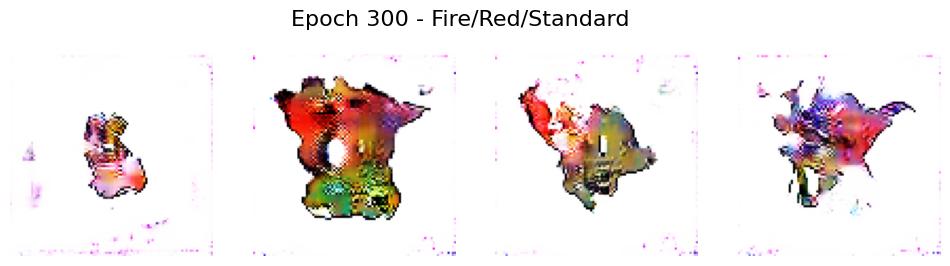

Epoch 300 Metrics: D_Loss: 0.0128 | G_Loss: 3.0363
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - d_loss: 0.0128 - g_loss: 3.0363


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tensorflow.keras import Model
import tensorflow as tf

# 1. Define the Custom Training Loop Class
class MultiConditionalGAN(Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(MultiConditionalGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def call(self, inputs):
        return inputs

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(MultiConditionalGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    @tf.function
    def train_step(self, data):
        real_images, labels = data
        batch_size = tf.shape(real_images)[0] 

        t_lbl = labels["type_input"]
        c_lbl = labels["color_input"]
        l_lbl = labels["leg_input"]

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        
        # Train Discriminator 
        with tf.GradientTape() as tape:
            fake_images = self.generator([random_latent_vectors, t_lbl, c_lbl, l_lbl], training=True)
            
            predictions_real = self.discriminator([real_images, t_lbl, c_lbl, l_lbl], training=True)
            predictions_fake = self.discriminator([fake_images, t_lbl, c_lbl, l_lbl], training=True)
            
            d_loss_real = self.loss_fn(tf.ones_like(predictions_real), predictions_real)
            d_loss_fake = self.loss_fn(tf.zeros_like(predictions_fake), predictions_fake)
            d_loss = d_loss_real + d_loss_fake
            
        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Train Generator
        with tf.GradientTape() as tape:
            fake_images = self.generator([random_latent_vectors, t_lbl, c_lbl, l_lbl], training=True)
            predictions_fake = self.discriminator([fake_images, t_lbl, c_lbl, l_lbl], training=True)
            
            g_loss = self.loss_fn(tf.ones_like(predictions_fake), predictions_fake)
            
        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        
        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

# 2. Define the Visual Checkpoint Callback
class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, num_img=4, latent_dim=100):
        self.num_img = num_img
        self.latent_dim = latent_dim
        
        # We lock in 4 identical requests to watch them evolve over time
        self.req_type = np.array([type_encoder.transform(["Fire"])[0]] * num_img)
        self.req_color = np.array([color_encoder.transform(["Red"])[0]] * num_img)
        self.req_leg = np.array([0] * num_img) # 0 = Standard, 1 = Legendary
        
        # Keep the exact same noise seed so we see the exact same "creatures" evolve
        self.seed_noise = tf.random.normal([num_img, latent_dim])

    def on_epoch_end(self, epoch, logs=None):
        # Generate the images
        t_req = tf.convert_to_tensor(self.req_type, dtype=tf.float32)
        c_req = tf.convert_to_tensor(self.req_color, dtype=tf.float32)
        l_req = tf.convert_to_tensor(self.req_leg, dtype=tf.float32)
        
        generated_images = self.model.generator([self.seed_noise, t_req, c_req, l_req], training=False)
        generated_images = (generated_images + 1) / 2.0 # Un-normalize for plotting
        
        # Clear the previous epoch's output to keep the notebook clean
        clear_output(wait=True)
        
        fig, axes = plt.subplots(1, self.num_img, figsize=(12, 3))
        fig.suptitle(f'Epoch {epoch+1} - Fire/Red/Standard', fontsize=16)
        
        for i in range(self.num_img):
            axes[i].imshow(generated_images[i].numpy())
            axes[i].axis('off')
            
        plt.show()
        print(f"Epoch {epoch+1} Metrics: D_Loss: {logs['d_loss']:.4f} | G_Loss: {logs['g_loss']:.4f}")

# 3. Distributed training
strategy = tf.distribute.MirroredStrategy()
print(f"\nNumber of GPUs locked in: {strategy.num_replicas_in_sync}\n")

with strategy.scope():
    LATENT_DIM = 100
    
    # Instantiate the models inside the scope
    generator = build_multi_generator(latent_dim=LATENT_DIM)
    discriminator = build_multi_discriminator(img_shape=(96, 96, 3))

    # Build the GAN wrapper
    cgan = MultiConditionalGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

    # 1. Create the optimizers explicitly
    d_opt = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    g_opt = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

    # 2. Force Keras to build the optimizer memory slots on both GPUs beforehand
    d_opt.build(discriminator.trainable_variables)
    g_opt.build(generator.trainable_variables)

    # 3. Compile using the pre-built optimizers
    cgan.compile(
        d_optimizer=d_opt,
        g_optimizer=g_opt,
        loss_fn=tf.keras.losses.BinaryCrossentropy()
    )

# 4. Start training
print("Starting training")
EPOCHS = 300

history = cgan.fit(dataset, epochs=EPOCHS, callbacks=[GANMonitor(num_img=4, latent_dim=LATENT_DIM)])

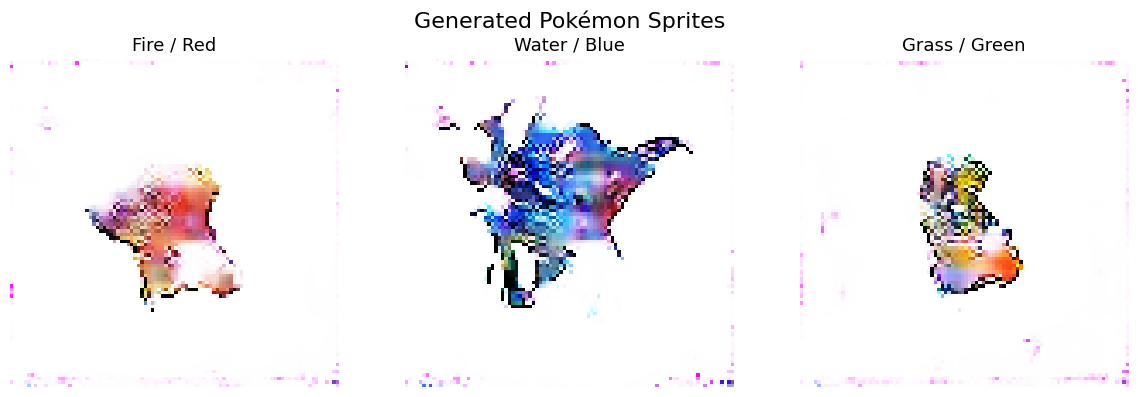

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 3 requests
requests = [
    {"type": "Fire",  "color": "Red",   "leg": 0},
    {"type": "Water", "color": "Blue",  "leg": 0},
    {"type": "Grass", "color": "Green", "leg": 0},
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Generated Pokémon Sprites", fontsize=16)

for i, req in enumerate(requests):
    # 2. Encode the labels
    req_type  = type_encoder.transform([req["type"]])[0]
    req_color = color_encoder.transform([req["color"]])[0]
    req_leg   = req["leg"]

    # 3. Build inputs
    inputs = [
        tf.random.normal([1, 100]),
        tf.constant([[req_type]],  dtype=tf.int32),
        tf.constant([[req_color]], dtype=tf.int32),
        tf.constant([[req_leg]],   dtype=tf.float32),
    ]

    # 4. Generate and un-normalize
    sprite = generator(inputs, training=False)[0].numpy()
    sprite = (sprite + 1) / 2.0

    # 5. Plot
    axes[i].imshow(sprite)
    axes[i].set_title(f"{req['type']} / {req['color']}", fontsize=13)
    axes[i].axis("off")

plt.tight_layout()
plt.show()